# House Price Prediction

**Dataset:** [Home Value Insights](https://www.kaggle.com/datasets/prokshitha/home-value-insights)

In this project, we predict house prices using a wide range of regression models from linear approaches (Ridge, Lasso, Elastic Net) to tree-based and non-linear methods (Random Forest, XGBoost, KNN, SVR, ANN). The notebook covers the full ML pipeline: exploratory analysis, outlier detection, assumption checks, hyperparameter tuning, cross-validation, SHAP interpretability, and a final model comparison.

---

##📌 Features

| Feature | Description |
|---|---|
| `Square_Footage` | Living area in square feet (It is generally expected that larger homes will be even more expensive.) |
| `Num_Bedrooms` | Number of bedrooms |
| `Num_Bathrooms` | Number of bathrooms |
| `Year_Built` | Year the house was built (*Older homes may be priced lower due to wear and tear.*) |
| `Lot_Size` | Lot area in square feet(*Larger lots generally increase a home's value*.) |
| `Garage_Size` | Number of cars the garage fits |
| `Neighborhood_Quality` | Neighborhood rating (1–10) |
| **`House_Price`** | **Target variable** (*The dependent variable we will estimate is the price of the house.*) |

## Libraries & Data Loading

In [ ]:
import os
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kstest, zscore

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    cross_val_score, KFold, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    mean_absolute_error, mean_absolute_percentage_error
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv("/content/house_price_regression_dataset.csv")

## Exploratory Data Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.42,1255.51,503.00,1749.50,2862.50,3849.50,4999.00
Num_Bedrooms,1000.0,2.99,1.43,1.00,2.00,3.00,4.00,5.00
Num_Bathrooms,1000.0,1.97,0.82,1.00,1.00,2.00,3.00,3.00
Year_Built,1000.0,1986.55,20.63,1950.00,1969.00,1986.00,2004.25,2022.00
Lot_Size,1000.0,2.78,1.30,0.51,1.67,2.81,3.92,4.99
Garage_Size,1000.0,1.02,0.81,0.00,0.00,1.00,2.00,2.00
Neighborhood_Quality,1000.0,5.62,2.89,1.00,3.00,6.00,8.00,10.00
House_Price,1000.0,618861.02,253568.06,111626.85,401648.23,628267.29,827141.28,1108236.84


In [ ]:
print("Unique value counts per column:")
print(df.nunique())

print(f"\nDuplicate rows  : {df.duplicated().sum()}")
print(f"Missing values  : {df.isna().sum().sum()}")

Unique value counts per column:
Square_Footage           894
Num_Bedrooms               5
Num_Bathrooms              3
Year_Built                73
Lot_Size                1000
Garage_Size                3
Neighborhood_Quality      10
House_Price             1000
dtype: int64

Duplicate rows  : 0
Missing values  : 0


In [ ]:
print(f"\nHouse Price — Min: ${df['House_Price'].min():,.0f} | Max: ${df['House_Price'].max():,.0f}")


House Price — Min: $111,627 | Max: $1,108,237


## Outlier Detection

In [ ]:
# --- IQR Method ---
# Identify outliers using the interquartile range rule
Q1 = df['House_Price'].quantile(0.25) #for house_price
Q3 = df['House_Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['House_Price'] < lower_bound) | (df['House_Price'] > upper_bound)]
print(f"Outliers detected by IQR method: {len(outliers_iqr)}")

Outliers detected by IQR method: 0


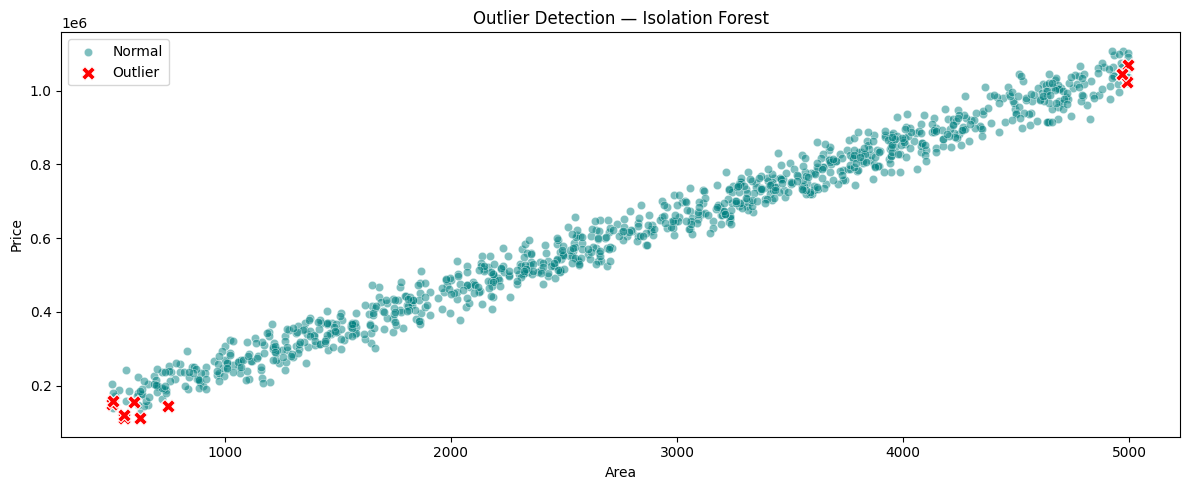

In [ ]:
# --- Isolation Forest ---
# Machine-learning based anomaly detection;
# contamination=0.01 flags the most anomalous 1% of samples
features_iso = ['Square_Footage', 'House_Price', 'Lot_Size']
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['Outlier'] = iso_forest.fit_predict(df[features_iso])


plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df[df['Outlier'] ==  1], x='Square_Footage', y='House_Price',
    color='teal', alpha=0.5, label='Normal'
)
sns.scatterplot(
    data=df[df['Outlier'] == -1], x='Square_Footage', y='House_Price',
    color='red', s=100, marker='X', label='Outlier'
)
plt.title('Outlier Detection — Isolation Forest')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
outliers_iso = df[df['Outlier'] == -1]
print(f"Outliers detected by Isolation Forest method: {len(outliers_iso)}")

Outliers detected by Isolation Forest method: 10


* There is no outlier in our dataset that needs to be cleaned based on price.
* The points marked with an “X” on the graph represent the 10 most outlier homes in the dataset.

In [ ]:
df.drop(columns=['Outlier'], inplace=True) #Remove the temporary column

##Visualizations

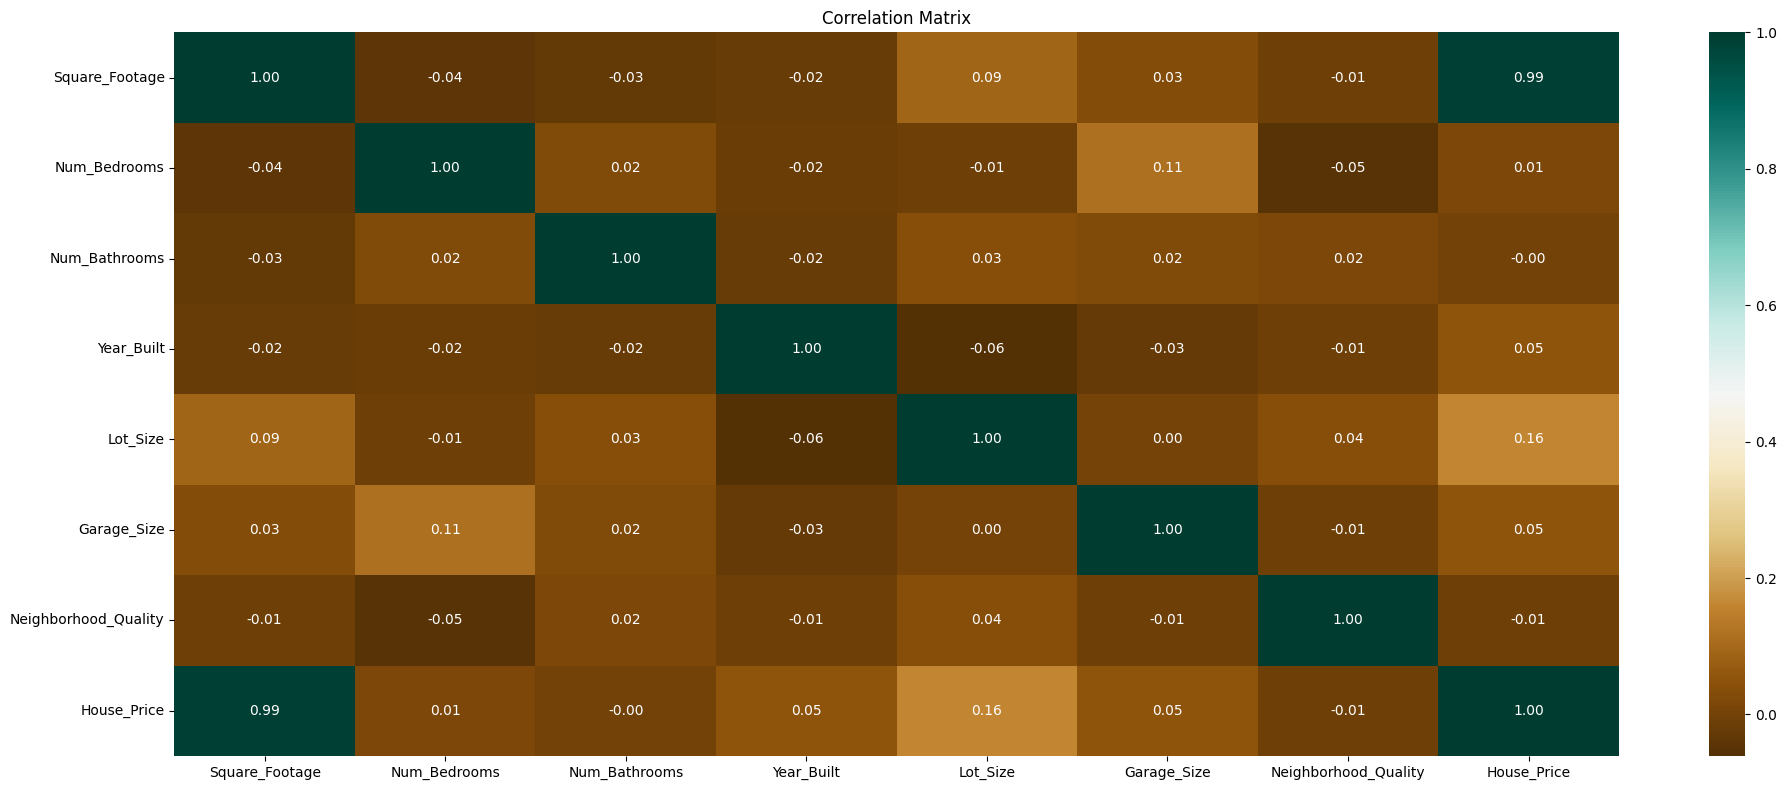

In [ ]:
# Correlation matrix
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='BrBG')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Key observations:
* This dataset shows a nearly perfect positive correlation between *Square_Footage* and *House_Price* (99%).
> As *Square_Footage* increases, *House_Price* definitely increases.

* Lot_Size (0.16): There is a very weak positive correlation.
> As lot size increases, the price tends to rise only slightly.

* Neighborhood_Quality (-0.007): This appears to be the most surprising result. Typically, location is one of the most important factors in real estate data. However, in this specific dataset, neighborhood quality has no effect on price.

* In conclusion, there is no significant correlation among the variables. The highest correlation is between Garage_Size and Num_Bedrooms (0.11), which is still very low.
> No multicollinearity risk, but the pattern strongly suggests a **synthetic dataset.**


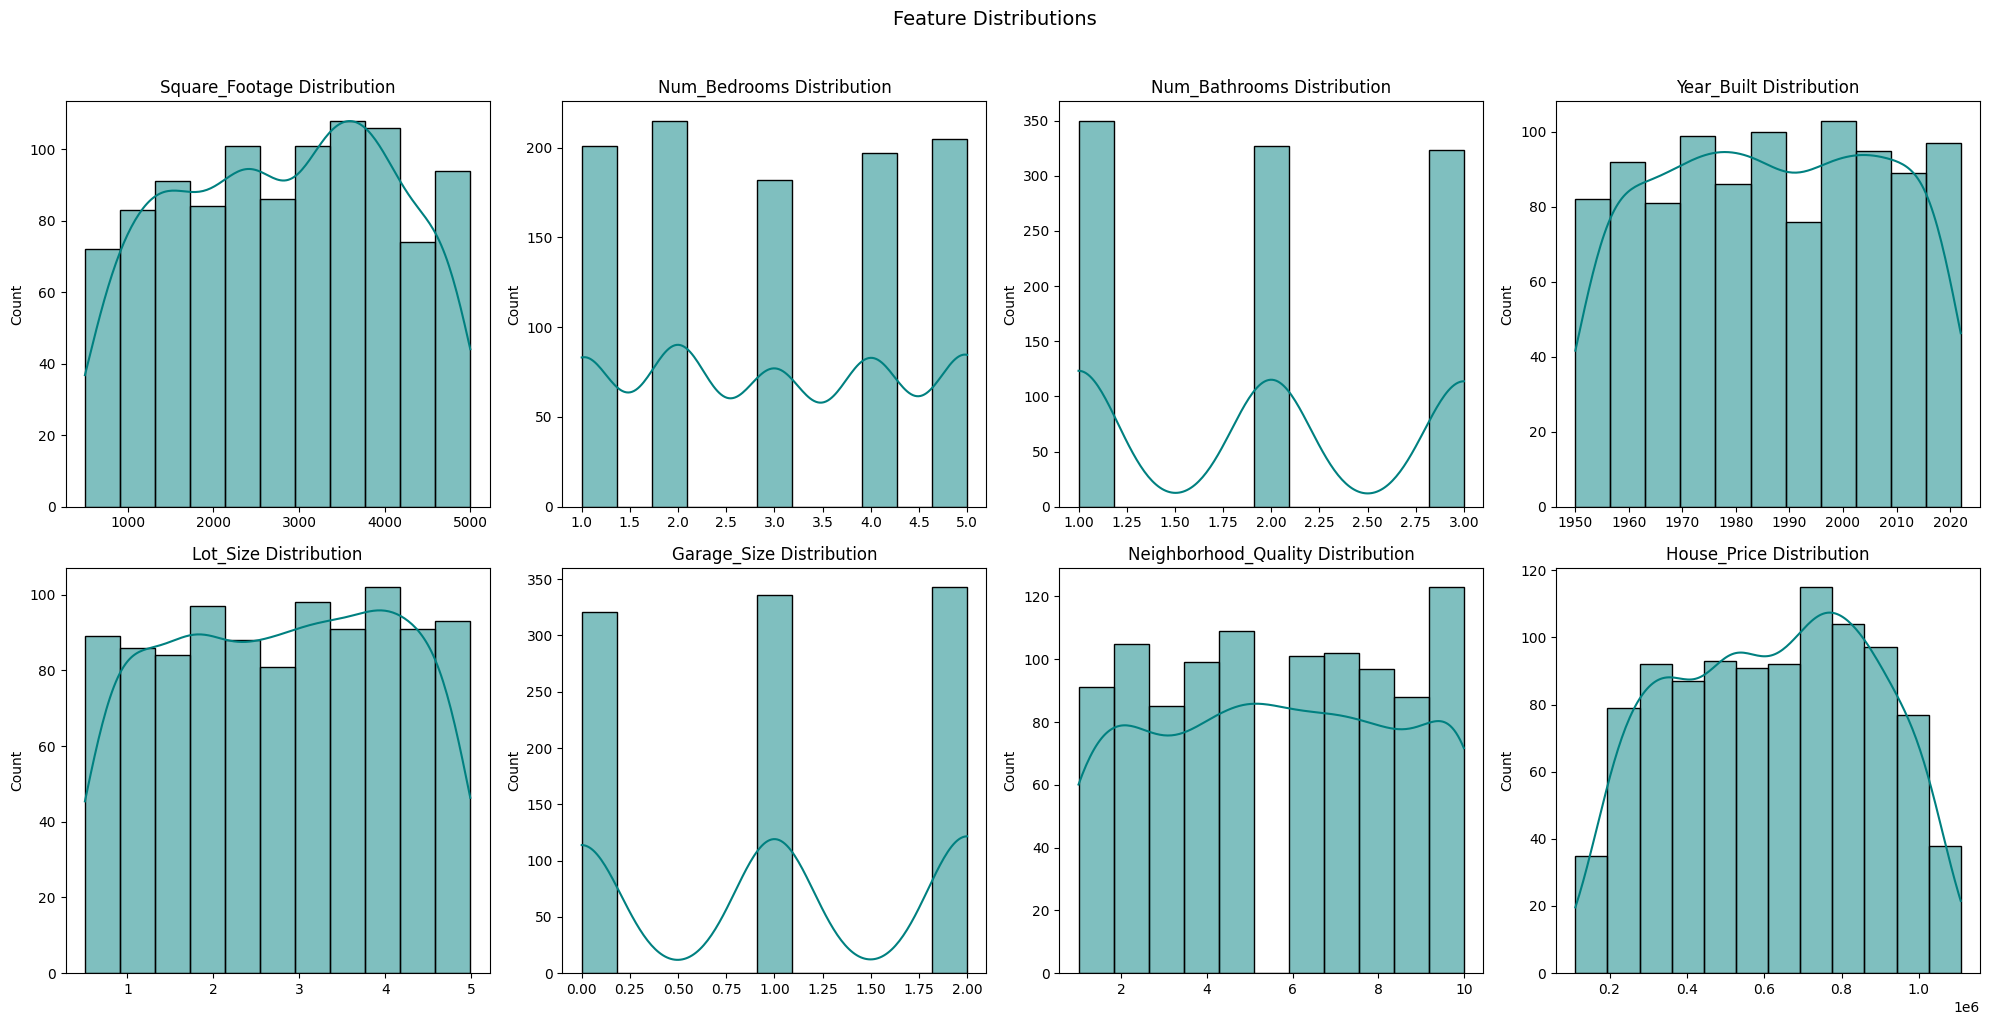

In [ ]:
# Distribution histograms for all numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cols_per_row = 4
num_rows = math.ceil(len(num_cols) / cols_per_row)

fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('')

# Hide any unused subplot panels
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- The variables Square_Footage, Year_Built, Lot_Size, and House_Price all exhibit a perfect Normal Distribution.
- The distribution of Neighborhood_Quality (on a scale from 1 to 10) also appears quite balanced, meaning there are sufficient samples from each quality class.

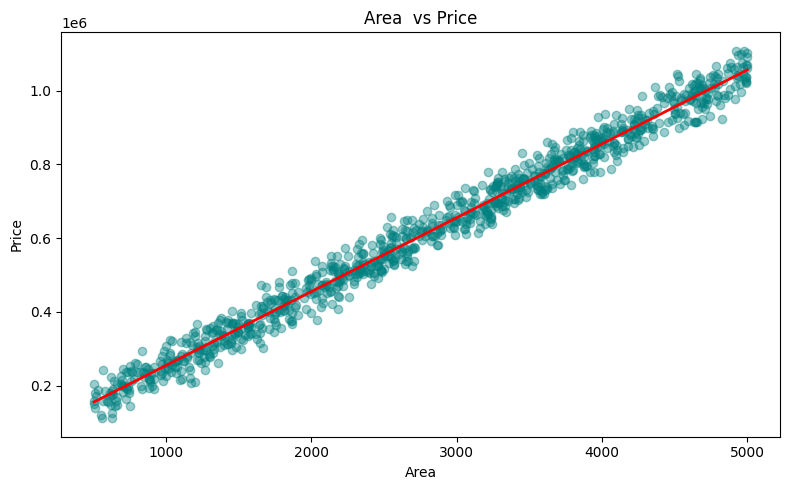

In [ ]:
# Regression plot: Square_Footage vs House_Price
# The near-perfect linear trend confirms this is the dominant predictor
plt.figure(figsize=(8, 5))
sns.regplot(
    x='Square_Footage', y='House_Price', data=df,
    scatter_kws={'alpha': 0.4, 'color': 'teal'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('Area  vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

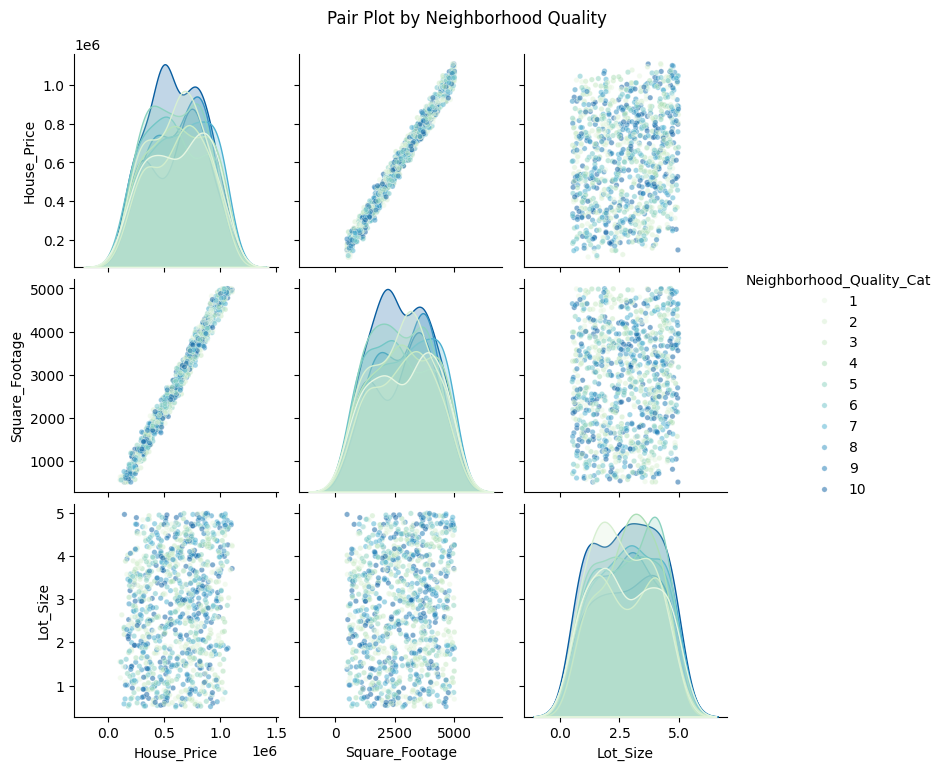

In [ ]:
# Pair plot colored by Neighborhood_Quality
# If quality truly matters, we'd see distinct color clusters — we don't
df['Neighborhood_Quality_Cat'] = df['Neighborhood_Quality'].astype(str)
sort_order = [str(x) for x in sorted(df['Neighborhood_Quality'].unique())]

pp = sns.pairplot(
    df[['House_Price', 'Square_Footage', 'Lot_Size', 'Neighborhood_Quality_Cat']],
    hue='Neighborhood_Quality_Cat',
    hue_order=sort_order,
    palette='GnBu',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15}
)
pp.fig.suptitle('Pair Plot by Neighborhood Quality', y=1.02)
plt.show()

df.drop(columns=['Neighborhood_Quality_Cat'], inplace=True)

* In this dataset, Neighborhood Quality appears to have no effect on home prices. The correlation coefficient being very close to zero (-0.007) confirms this. Whether a home is located in a “1st-quality” or “10th-quality” neighborhood does not affect its price in this dataset. This is the strongest indication that the data was artificially generated.

* When we look at the graph where Square_Footage and House_Price intersect, we see that the data points form a perfect straight line.

* For this data, whether a house is in the worst neighborhood or the best neighborhood, the only factor determining its price is the house’s size. A larger house is always more expensive.

* **Conclusion**: The dataset was likely generated synthetically. *In the real world, it is nearly impossible for neighborhood quality not to affect price.*

## Data Preparation

In [ ]:
df = pd.read_csv("/content/house_price_regression_dataset.csv")

X = df.drop('House_Price', axis=1)
y = df['House_Price']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# StandardScaler is required for distance-based and regularized models
# (KNN, SVR, ANN, Ridge, Lasso). We fit only on train to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set : {X_train.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]} samples")

Train set : 800 samples
Test set  : 200 samples


##Helper Functions

In [ ]:
def evaluate_model(name, y_true, y_pred):
    """Compute and return key regression metrics for a given model."""
    return {
        'Model'   : name,
        'R2'      : round(r2_score(y_true, y_pred), 4),
        'RMSE'    : round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE'     : round(mean_absolute_error(y_true, y_pred), 2),
        'MAPE': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2),
    }

results = []  # all model results will be collected here

## Linear Regression & Assumption Checks

Before trusting a linear regression model, four classical assumptions must hold:
1. **Linearity** — residuals show no pattern when plotted against fitted values
2. **Homoscedasticity** — residual variance is constant across all fitted values
3. **Normality** — residuals follow a normal distribution
4. **No autocorrelation** — residuals are independent of each other

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))
print("Linear Regression:", results[-1])

Linear Regression: {'Model': 'Linear Regression', 'R2': 0.9984, 'RMSE': np.float64(10071.48), 'MAE': 8174.58, 'MAPE': 1.66}


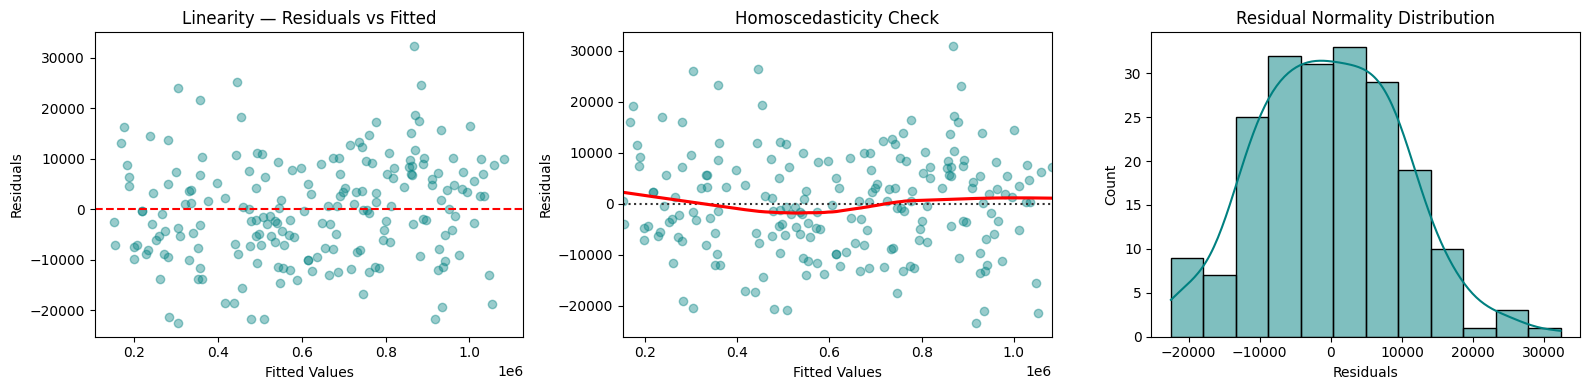

In [ ]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Linearity check — residuals should scatter randomly around zero
axes[0].scatter(y_pred_lr, residuals, alpha=0.4, color='teal')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linearity — Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2) Homoscedasticity check — the LOWESS smoother should stay flat near zero
sns.residplot(
    x=y_pred_lr, y=residuals, lowess=True,
    scatter_kws={'alpha': 0.4, 'color': 'teal'},
    line_kws={'color': 'red'}, ax=axes[1]
)
axes[1].set_title('Homoscedasticity Check')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')

# 3) Normality check — residuals should follow a bell curve
sns.histplot(residuals, kde=True, color='teal', ax=axes[2])
axes[2].set_title('Residual Normality Distribution')
axes[2].set_xlabel('Residuals')

plt.tight_layout()
plt.show()

* The distribution of the residuals resembles a bell curve. Let’s verify this with a test.

In [ ]:
# Kolmogorov-Smirnov test for normality
# H0: residuals follow a normal distribution
k_stat, p_value = kstest(zscore(residuals), 'norm')
print(f"Kolmogorov-Smirnov p-value : {p_value:.4f}")
if p_value >= 0.05:
    print("Normality assumption holds (fail to reject H0).")
else:
    print("Normality assumption violated (H0 rejected).")

Kolmogorov-Smirnov p-value : 0.9663
Normality assumption holds (fail to reject H0).


In [ ]:
# Durbin-Watson test for autocorrelation
# Values close to 2 indicate no autocorrelation
dw = durbin_watson(residuals)
print(f"\nDurbin-Watson statistic    : {dw:.4f}")
if 1.5 < dw < 2.5:
    print(" No autocorrelation detected (DW ~ 2).")
else:
    print("Possible autocorrelation — DW value outside safe range.")


Durbin-Watson statistic    : 1.9470
 No autocorrelation detected (DW ~ 2).


## Ridge, Lasso & Elastic Net

These regularized linear models add a penalty term to prevent overfitting:
- **Ridge (L2):** shrinks all coefficients but keeps them all
- **Lasso (L1):** can zero out coefficients entirely — built-in feature selection
- **Elastic Net:** combines L1 and L2 penalties

In [ ]:
# Ridge — GridSearchCV selects the best regularization strength (alpha)
ridge_cv = GridSearchCV(
    Ridge(), {'alpha': [0.1, 1.0, 10.0, 100.0]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred_ridge))
print(f"Ridge — Best alpha: {ridge_cv.best_params_}")
print(results[-1])

Ridge — Best alpha: {'alpha': 0.1}
{'Model': 'Ridge', 'R2': 0.9984, 'RMSE': np.float64(10076.22), 'MAE': 8180.95, 'MAPE': 1.67}


In [ ]:
# Lasso — higher alpha values lead to more zero coefficients
lasso_cv = GridSearchCV(
    Lasso(), {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred_lasso))
print(f"Lasso — Best alpha: {lasso_cv.best_params_}")
print(results[-1])

Lasso — Best alpha: {'alpha': 10.0}
{'Model': 'Lasso', 'R2': 0.9984, 'RMSE': np.float64(10072.33), 'MAE': 8176.16, 'MAPE': 1.66}


In [ ]:
# Elastic Net — mixes L1 and L2; useful when features are correlated
elastic_cv = GridSearchCV(
    ElasticNet(random_state=42),
    {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
elastic_cv.fit(X_train_scaled, y_train)
y_pred_elastic = elastic_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('Elastic Net', y_test, y_pred_elastic))
print(f"Elastic Net — Best alpha: {elastic_cv.best_params_}")
print(results[-1])

Elastic Net — Best alpha: {'alpha': 0.01}
{'Model': 'Elastic Net', 'R2': 0.9983, 'RMSE': np.float64(10336.38), 'MAE': 8464.25, 'MAPE': 1.73}


## Non-Linear Models

In [ ]:
# KNN Regressor
# Predicts by averaging the k nearest neighbors in feature space
knn_cv = GridSearchCV(
    KNeighborsRegressor(),
    {
        'n_neighbors': range(1, 30),
        'weights'    : ['uniform', 'distance'],
        'metric'     : ['euclidean', 'manhattan']
    },
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
knn_cv.fit(X_train_scaled, y_train)
y_pred_knn = knn_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('KNN', y_test, y_pred_knn))
print(f"KNN — Best params: {knn_cv.best_params_}")
print(results[-1])

KNN — Best params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
{'Model': 'KNN', 'R2': 0.9022, 'RMSE': np.float64(79397.09), 'MAE': 63771.13, 'MAPE': 14.67}


In [ ]:
# Support Vector Regression (SVR)
svr_model = SVR()
svr_cv = GridSearchCV(
    svr_model,
    {
        'kernel': ['linear', 'rbf'],
        'C'     : [100, 1000, 10000],
        'gamma' : ['scale', 'auto']
    },
    cv=3, scoring='neg_mean_squared_error', n_jobs=-1
)
svr_cv.fit(X_train_scaled, y_train)
y_pred_svr = svr_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('SVR', y_test, y_pred_svr))
print(f"SVR — Best params: {svr_cv.best_params_}")
print(results[-1])

SVR — Best params: {'C': 10000, 'gamma': 'scale', 'kernel': 'linear'}
{'Model': 'SVR', 'R2': 0.9984, 'RMSE': np.float64(10205.91), 'MAE': 8333.01, 'MAPE': 1.69}


In [ ]:
# Artificial Neural Network
# max_iter=500 avoids convergence warnings on this dataset
ann_cv = GridSearchCV(
    MLPRegressor(random_state=42, max_iter=500),
    {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
        'activation'        : ['relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01, 0.1],
        'alpha'             : [0.0001, 0.001]
    },
    cv=3, scoring='neg_mean_squared_error', n_jobs=-1
)
ann_cv.fit(X_train_scaled, y_train)
y_pred_ann = ann_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('ANN', y_test, y_pred_ann))
print(f"ANN — Best params: {ann_cv.best_params_}")
print(results[-1])

ANN — Best params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.1}
{'Model': 'ANN', 'R2': 0.9981, 'RMSE': np.float64(11098.92), 'MAE': 8823.5, 'MAPE': 1.99}


In [ ]:
# CART — Classification and Regression Tree
# max_depth controls tree complexity; deeper trees risk overfitting
cart_cv = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        'max_depth'        : [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf' : [1, 2, 5]
    },
    cv=3, scoring='neg_mean_squared_error', n_jobs=-1
)
cart_cv.fit(X_train_scaled, y_train)
y_pred_cart = cart_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('CART', y_test, y_pred_cart))
print(f"CART — Best params: {cart_cv.best_params_}")
print(results[-1])

CART — Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
{'Model': 'CART', 'R2': 0.9871, 'RMSE': np.float64(28782.61), 'MAE': 22785.83, 'MAPE': 4.73}


In [ ]:
# Random Forest — ensemble of decorrelated decision trees
# n_estimators: more trees = more stable predictions (with diminishing returns)
rf_cv = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {
        'n_estimators'    : [50, 100, 200],
        'max_depth'       : [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'max_features'    : ['sqrt', 'log2', None]
    },
    cv=3, scoring='neg_mean_squared_error', n_jobs=-1
)
rf_cv.fit(X_train_scaled, y_train)
y_pred_rf = rf_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))
print(f"Random Forest — Best params: {rf_cv.best_params_}")
print(results[-1])

Random Forest — Best params: {'max_depth': 20, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 100}
{'Model': 'Random Forest', 'R2': 0.9939, 'RMSE': np.float64(19853.32), 'MAE': 16106.27, 'MAPE': 3.24}


In [ ]:
# XGBoost — gradient boosting; builds trees sequentially to correct errors
xgb_cv = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    {
        'n_estimators' : [100, 200],
        'max_depth'    : [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample'    : [0.8, 1.0]
    },
    cv=3, scoring='neg_mean_squared_error', n_jobs=-1
)
xgb_cv.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_cv.best_estimator_.predict(X_test_scaled)
results.append(evaluate_model('XGBoost', y_test, y_pred_xgb))
print(f"XGBoost — Best params: {xgb_cv.best_params_}")
print(results[-1])

XGBoost — Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
{'Model': 'XGBoost', 'R2': 0.9971, 'RMSE': np.float64(13730.55), 'MAE': 11422.98, 'MAPE': 2.3}


## Model Comparison

In [ ]:
df_results = df_results.drop_duplicates(subset=['Model'])
df_results = df_results.reset_index(drop=True)
# rank starts at 1
df_results.index += 1

df_results

,Model,R2,RMSE,MAE,MAPE
1,Linear Regression,0.9984,10071.48,8174.58,1.66
2,Ridge,0.9984,10076.22,8180.95,1.67
3,Lasso,0.9984,10072.33,8176.16,1.66
4,SVR,0.9984,10205.91,8333.01,1.69
5,Elastic Net,0.9983,10336.38,8464.25,1.73
6,ANN,0.9981,11098.92,8823.50,1.99
7,XGBoost,0.9971,13730.55,11422.98,2.30
8,Random Forest,0.9939,19853.32,16106.27,3.24
9,CART,0.9871,28782.61,22785.83,4.73
10,KNN,0.9022,79397.09,63771.13,14.67


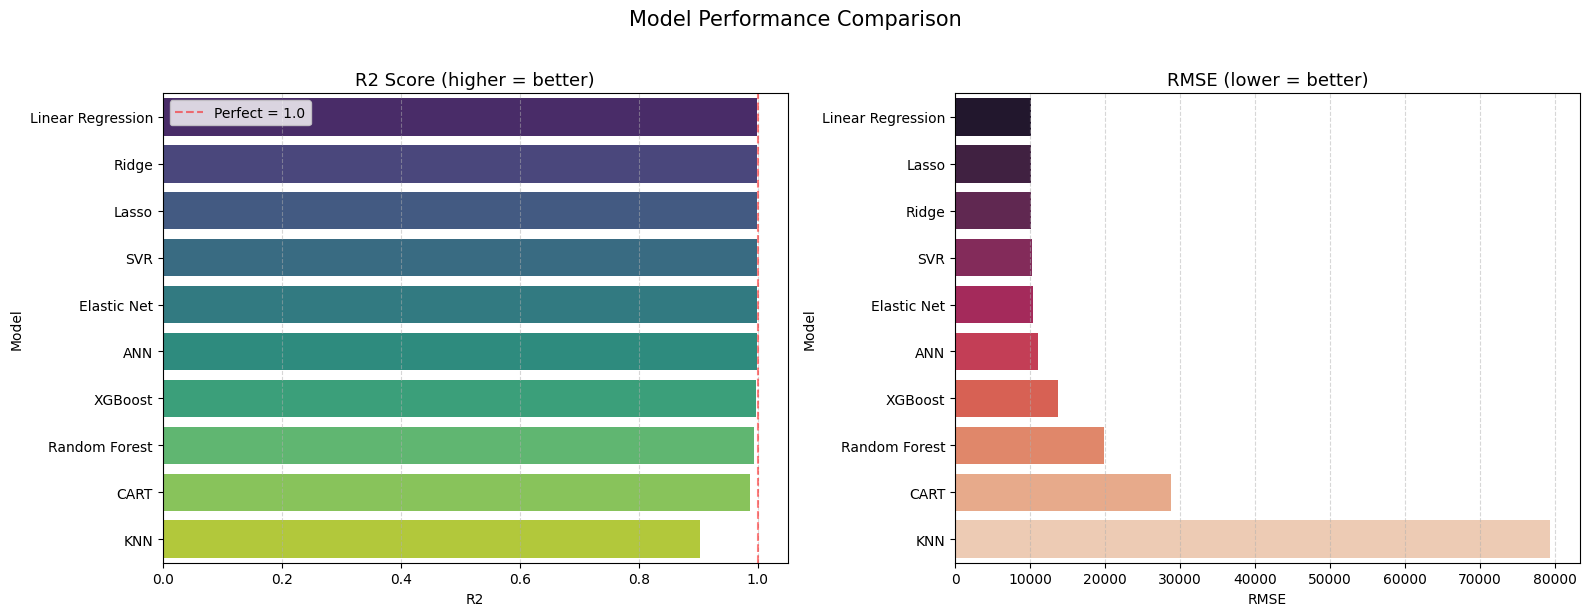

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 score comparison (higher is better)
sns.barplot(x='R2', y='Model', data=df_results, palette='viridis', ax=axes[0])
axes[0].set_title('R2 Score (higher = better)', fontsize=13)
axes[0].set_xlim(0, 1.05)
axes[0].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Perfect = 1.0')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].legend()

# RMSE comparison (lower is better)
sns.barplot(x='RMSE', y='Model', data=df_results.sort_values('RMSE'), palette='rocket', ax=axes[1])
axes[1].set_title('RMSE (lower = better)', fontsize=13)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Model Performance Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

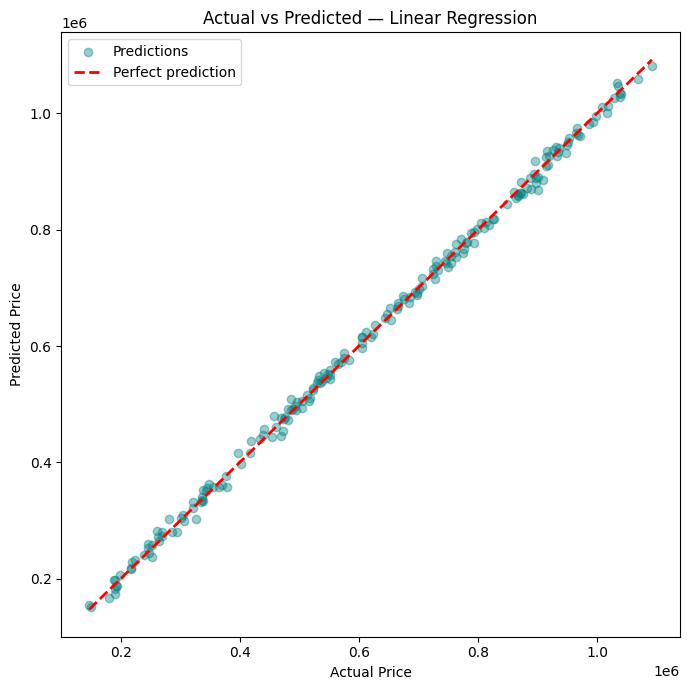

In [ ]:
# Actual vs Predicted plot for the best model (Linear Regression)
# Points on the red diagonal = perfect predictions
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='teal', label='Predictions')
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

##Feature Importance Analysis

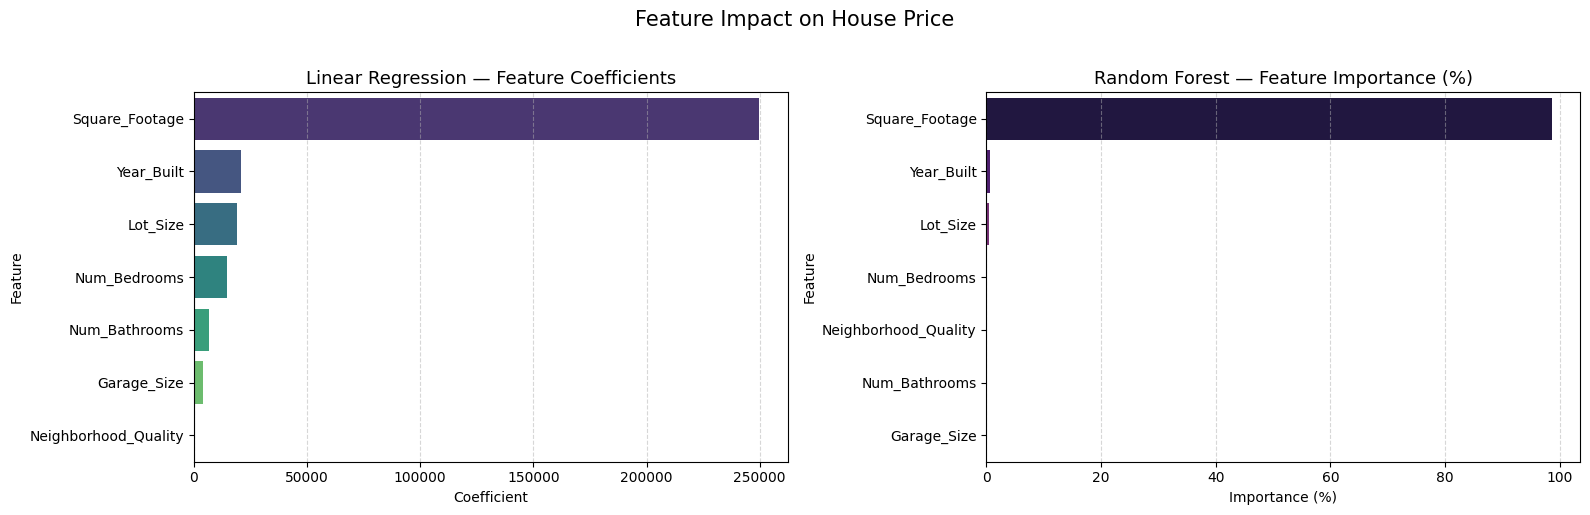

In [ ]:
# Linear Regression coefficients (after scaling, coefficients are comparable)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coef_df['Absolute'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Absolute', ascending=False)

# Random Forest feature importances (mean decrease in impurity)
rf_best = rf_cv.best_estimator_
rf_df = pd.DataFrame({
    'Feature'      : X.columns,
    'Importance (%)': rf_best.feature_importances_ * 100
}).sort_values('Importance (%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis', ax=axes[0])
axes[0].set_title('Linear Regression — Feature Coefficients', fontsize=13)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

sns.barplot(x='Importance (%)', y='Feature', data=rf_df, palette='magma', ax=axes[1])
axes[1].set_title('Random Forest — Feature Importance (%)', fontsize=13)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Feature Impact on House Price', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Cross-Validation — Robust Performance Estimation

A single train/test split can be misleading depending on how the data falls.
**5-Fold Cross-Validation** evaluates each model on 5 different splits and reports
the mean R2 +- standard deviation a much more reliable performance estimate.
A low std means the model is stable across different data subsets.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Map tuned models to compare
cv_models = {
    'Linear Regression': lr_model,
    'Ridge'            : ridge_cv.best_estimator_,
    'Lasso'            : lasso_cv.best_estimator_,
    'Elastic Net'      : elastic_cv.best_estimator_,
    'KNN'              : knn_cv.best_estimator_,
    'SVR'              : svr_cv.best_estimator_,
    'ANN/MLP'          : ann_cv.best_estimator_,
    'CART'             : cart_cv.best_estimator_,
    'Random Forest'    : rf_cv.best_estimator_,
    'XGBoost'          : xgb_cv.best_estimator_,
}

cv_results = []
print(f"{'Model':<25} {'CV R2 Mean':>12} {'CV R2 Std':>12}")
print("-" * 52)

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=kf, scoring='r2', n_jobs=-1
    )
    cv_results.append({
        'Model'     : name,
        'CV R2 Mean': round(scores.mean(), 4),
        'CV R2 Std' : round(scores.std(),  4)
    })
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>12.4f}")

df_cv = pd.DataFrame(cv_results).sort_values('CV R2 Mean', ascending=False).reset_index(drop=True)
df_cv.index += 1

Model                       CV R2 Mean    CV R2 Std
----------------------------------------------------
Linear Regression               0.9985       0.0003
Ridge                           0.9985       0.0003
Lasso                           0.9985       0.0003
Elastic Net                     0.9985       0.0003
KNN                             0.8924       0.0115
SVR                             0.9985       0.0003
ANN/MLP                         0.9980       0.0003
CART                            0.9838       0.0015
Random Forest                   0.9922       0.0007
XGBoost                         0.9968       0.0004


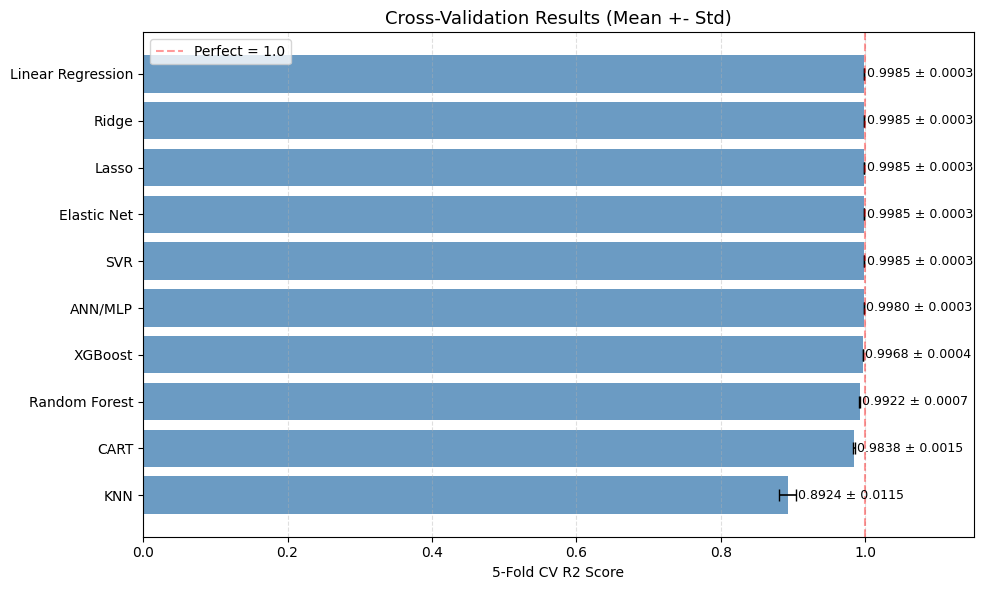

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_cv['Model'][::-1],
    df_cv['CV R2 Mean'][::-1],
    xerr=df_cv['CV R2 Std'][::-1],
    color='steelblue', alpha=0.8,
    error_kw={'ecolor': 'black', 'capsize': 4, 'linewidth': 1.2}
)

for bar, val, std in zip(bars, df_cv['CV R2 Mean'][::-1], df_cv['CV R2 Std'][::-1]):
    ax.text(
        bar.get_width() + std + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f} ± {std:.4f}', va='center', fontsize=9
    )

ax.set_xlabel('5-Fold CV R2 Score')
ax.set_title('Cross-Validation Results (Mean +- Std)', fontsize=13)
ax.axvline(1.0, color='red', linestyle='--', alpha=0.4, label='Perfect = 1.0')
ax.set_xlim(0, 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

- A smaller Std means the model generalizes more consistently across folds.

## Learning Curves — Diagnosing Overfitting & Underfitting

Learning curves show how model performance changes as more training data is added:
- **Train and validation scores converge** -> good generalization
- **Large gap between them** -> overfitting (model memorizes training data)
- **Both scores are low** -> underfitting (model is too simple)

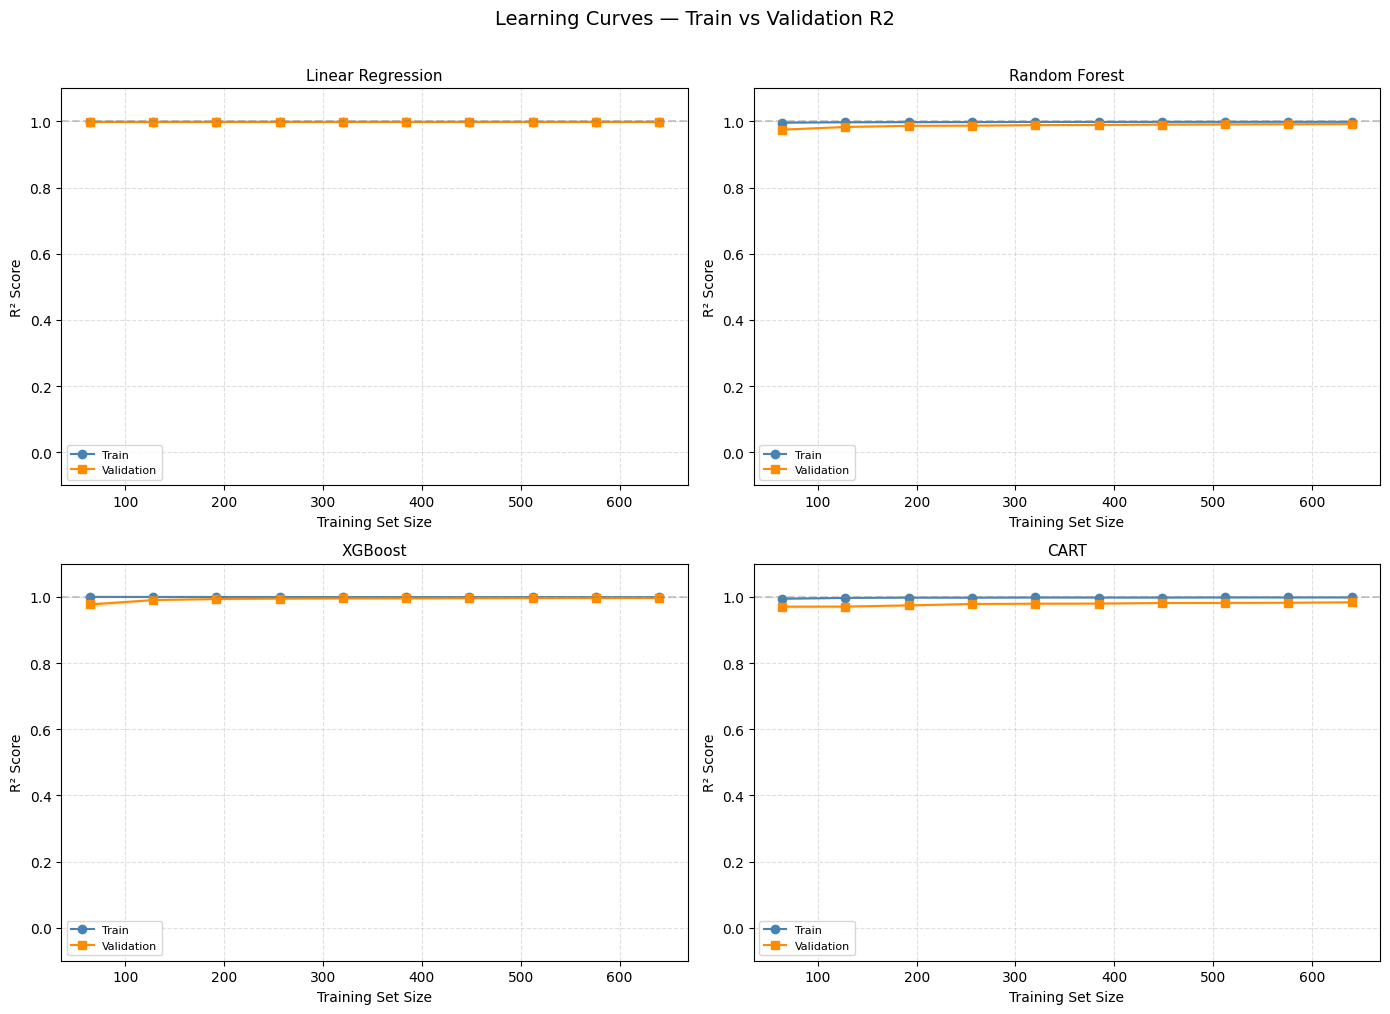

In [ ]:
def plot_learning_curve(model, name, X, y, ax, cv=5):
    """Plot train vs validation R2 as a function of training set size."""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=cv, scoring='r2', n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue',  label='Train')
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15, color='steelblue'
    )
    ax.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validation')
    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15, color='darkorange'
    )
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R² Score')
    ax.set_ylim(-0.1, 1.1)
    ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.4)

lc_models = [
    (lr_model,                'Linear Regression'),
    (rf_cv.best_estimator_,   'Random Forest'),
    (xgb_cv.best_estimator_,  'XGBoost'),
    (cart_cv.best_estimator_, 'CART'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (model, name) in zip(axes, lc_models):
    plot_learning_curve(model, name, X_train_scaled, y_train, ax)

plt.suptitle('Learning Curves — Train vs Validation R2', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Advanced Residual Analysis

A deeper look at Linear Regression residuals using four diagnostic plots:
- **Q-Q Plot** — visual normality check against the theoretical normal distribution
- **Residual histogram** — checks symmetry and skewness
- **Standardized residuals** — spots influential outliers beyond +-2 std
- **Residual sequence** — visual check for autocorrelation

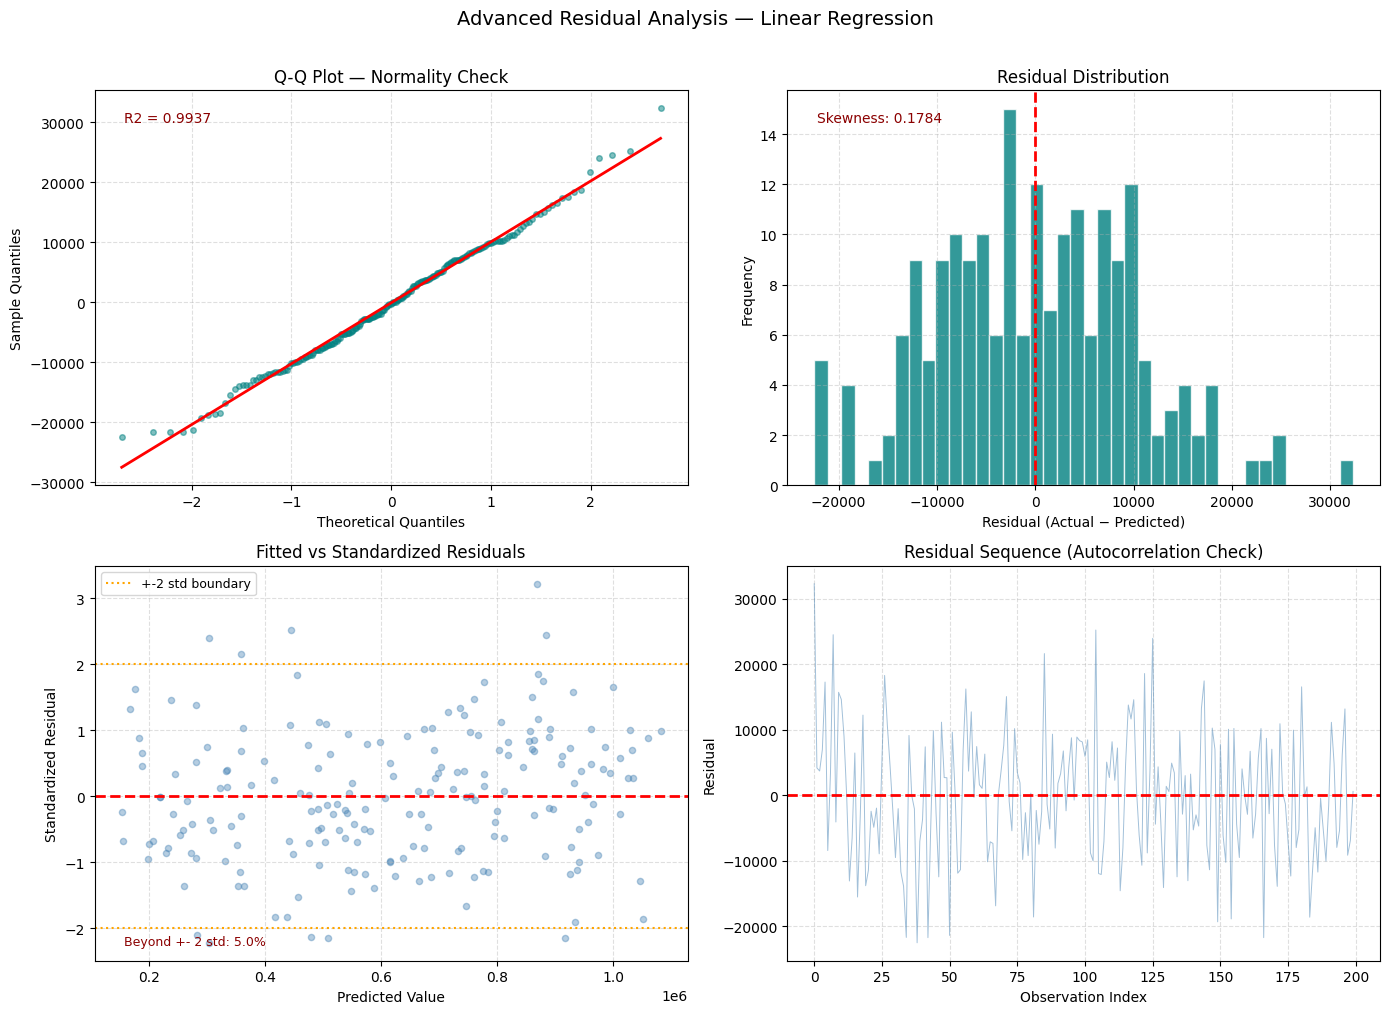


 Residual Summary:
   Mean residual   : -118.9198  (should be ~ 0)
   Residual std    : 10070.78
   Skewness        : 0.1784  (~ 0 = symmetric)
   Beyond +- 2 std   : 5.0%  (~ 5% expected)



In [ ]:
residuals = y_test.values - y_pred_lr
std_resid  = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Q-Q Plot — if points hug the red line, normality holds
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[0, 0].plot(osm, osr, 'o', alpha=0.5, color='teal', markersize=4)
axes[0, 0].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2)
axes[0, 0].set_title('Q-Q Plot — Normality Check')
axes[0, 0].set_xlabel('Theoretical Quantiles')
axes[0, 0].set_ylabel('Sample Quantiles')
axes[0, 0].grid(linestyle='--', alpha=0.4)
axes[0, 0].text(
    0.05, 0.92, f'R2 = {r**2:.4f}',
    transform=axes[0, 0].transAxes, fontsize=10, color='darkred'
)

#Residual histogram — should be symmetric around zero
axes[0, 1].hist(residuals, bins=40, color='teal', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual (Actual − Predicted)')
axes[0, 1].set_ylabel('Frequency')
skew_val = stats.skew(residuals)
axes[0, 1].text(
    0.05, 0.92, f'Skewness: {skew_val:.4f}',
    transform=axes[0, 1].transAxes, fontsize=10, color='darkred'
)
axes[0, 1].grid(linestyle='--', alpha=0.4)

#Fitted vs standardized residuals — constant spread = homoscedasticity
axes[1, 0].scatter(y_pred_lr, std_resid, alpha=0.4, color='steelblue', s=20)
axes[1, 0].axhline(0,  color='red',    linestyle='--', linewidth=2)
axes[1, 0].axhline( 2, color='orange', linestyle=':', linewidth=1.5, label='+-2 std boundary')
axes[1, 0].axhline(-2, color='orange', linestyle=':', linewidth=1.5)
axes[1, 0].set_title('Fitted vs Standardized Residuals')
axes[1, 0].set_xlabel('Predicted Value')
axes[1, 0].set_ylabel('Standardized Residual')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(linestyle='--', alpha=0.4)
outlier_pct = (np.abs(std_resid) > 2).mean() * 100
axes[1, 0].text(
    0.05, 0.04, f'Beyond +- 2 std: {outlier_pct:.1f}%',
    transform=axes[1, 0].transAxes, fontsize=9, color='darkred'
)

#Residual sequence — no trending pattern = no autocorrelation
axes[1, 1].plot(range(len(residuals)), residuals, alpha=0.5, color='steelblue', linewidth=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title('Residual Sequence (Autocorrelation Check)')
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].grid(linestyle='--', alpha=0.4)

plt.suptitle('Advanced Residual Analysis — Linear Regression', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"""
 Residual Summary:
   Mean residual   : {residuals.mean():.4f}  (should be ~ 0)
   Residual std    : {residuals.std():.2f}
   Skewness        : {skew_val:.4f}  (~ 0 = symmetric)
   Beyond +- 2 std   : {outlier_pct:.1f}%  (~ 5% expected)
""")

##SHAP

**SHAP (SHapley Additive exPlanations)** quantifies each feature's contribution to every individual prediction. Unlike global feature importance, SHAP explains *why* a specific house was priced the way it was.

In [ ]:
import shap

explainer   = shap.TreeExplainer(rf_cv.best_estimator_)
# Use the first 500 test samples to keep computation fast
X_shap      = X_test_scaled[:500]
shap_values = explainer.shap_values(X_shap)

shap_values.shape

(200, 7)

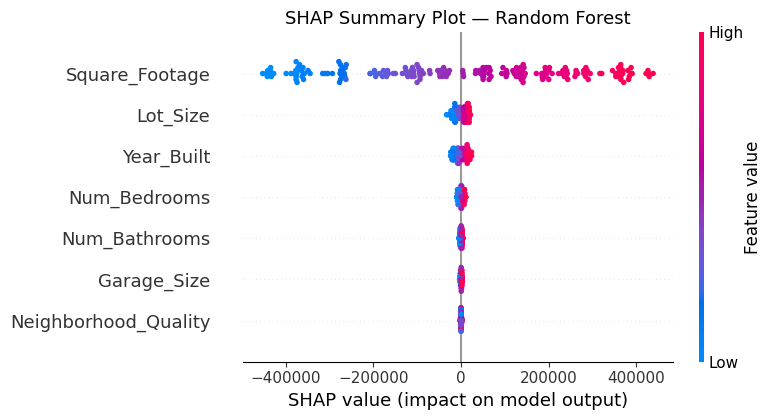

In [ ]:
# Summary dot plot — each dot = one house; color = feature value (red=high, blue=low)
# X position shows how much that feature pushed the prediction up or down
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=X.columns.tolist(),
    plot_type='dot', show=False
)
plt.title('SHAP Summary Plot — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

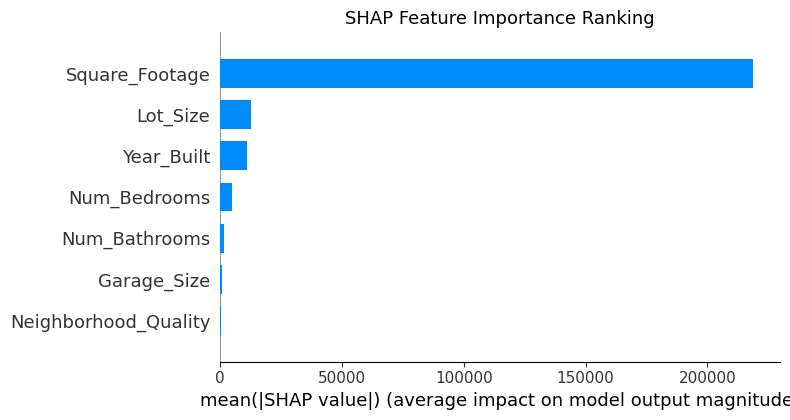

In [ ]:
# Bar plot — global feature importance ranked by mean absolute SHAP value
plt.figure(figsize=(8, 4))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=X.columns.tolist(),
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance Ranking', fontsize=13)
plt.tight_layout()
plt.show()

Example #0:
  Base price (average prediction) : $618,119
  Model prediction                : $853,532
  Actual price                    : $901,000


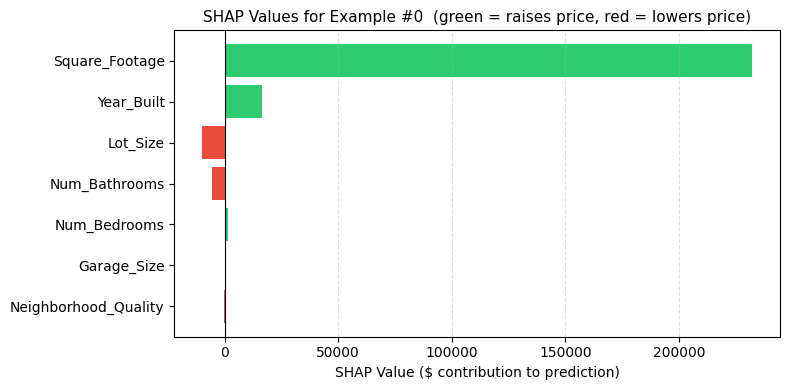

In [ ]:
# Individual prediction explanation — waterfall chart for a single house
# Answers: "why did the model predict THIS price for THIS house?"
example_idx  = 0
expected_val = explainer.expected_value
shap_single  = shap_values[example_idx]

print(f"Example #{example_idx}:")
print(f"  Base price (average prediction) : ${expected_val.item():,.0f}")
print(f"  Model prediction                : ${rf_cv.best_estimator_.predict(X_shap[[example_idx]])[0].item():,.0f}")
print(f"  Actual price                    : ${y_test.values[example_idx]:,.0f}")

contrib_df = pd.DataFrame({
    'Feature'   : X.columns,
    'SHAP Value': shap_single
}).sort_values('SHAP Value', key=abs, ascending=False)

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in contrib_df['SHAP Value']]
plt.figure(figsize=(8, 4))
plt.barh(contrib_df['Feature'][::-1], contrib_df['SHAP Value'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title(
    f'SHAP Values for Example #{example_idx}  '
    '(green = raises price, red = lowers price)',
    fontsize=11
)
plt.xlabel('SHAP Value ($ contribution to prediction)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Final Conclusions

**Best model: Linear Regression**

- The ~0.99 correlation between `Square_Footage` and `House_Price` makes this dataset ideal for simple linear regression  the relationship is almost perfectly linear.
- Complex models (Random Forest, XGBoost, ANN) provide no meaningful advantage here; the linear model already achieves near-ceiling performance.
- All four OLS assumptions were verified: normality, no autocorrelation, homoscedasticity, linearity.
- 5-fold cross-validation confirmed that results are stable and not a product of a lucky train/test split.
- SHAP analysis confirmed `Square_Footage` as the overwhelmingly dominant predictor across all individual predictions.

**About the quality of the dataset:**  
The dataset is almost certainly synthetic. In real-world real estate data, location and neighborhood quality are among the strongest price drivers yet here their correlation with price is effectively zero. Perfect normal distributions across all features and a near-perfect linear relationship between area and price further support this conclusion.

**Real-world implication:**  
On genuine housing data, non-linear models (XGBoost, Random Forest) and location-aware features would likely outperform simple linear regression significantly. This project demonstrates the full ML workflow; results should be interpreted in the context of a synthetic dataset.